<h1 style="text-align: center; color: green;">  Création de projet en IA</h1>
<h1 style="text-align: center; color: green;">  TP : Voitures Autonomes</h1>

<h2 style="color: brown;">Importation des bibliothèques nécessaires</h2>

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.image  as npimg
import os

import keras 
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense
import cv2
import pandas as pd
import random
import ntpath

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split


C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


<h2 style="color: brown;">Chargement des données et prétraitement initial</h2>

Ce code lit un fichier CSV contenant des données de conduite autonome. Voici ce que chaque partie du code fait :

- `datadir = 'Self-Driving-Car-master'`: Définit le répertoire où se trouve le fichier CSV contenant les données de conduite autonome. Dans ce cas, le répertoire est nommé 'Self-Driving-Car-master'.

- `columns = ['center', 'left', 'right', 'steering', 'throttle', 'reserve', 'speed']`: Crée une liste appelée columns contenant les noms des colonnes que le DataFrame aura après la lecture du fichier CSV. Ces noms correspondent aux différentes caractéristiques des données de conduite, telles que les images des caméras, les angles de direction, l'accélération, etc.

- `data = pd.read_csv(os.path.join(datadir, 'driving_log.csv'), names=columns)`: Utilise la bibliothèque pandas pour lire le fichier CSV contenant les données de conduite. Le paramètre names spécifie les noms des colonnes à utiliser pour le DataFrame. Le fichier CSV est lu depuis le chemin obtenu en joignant le répertoire datadir avec le nom du fichier CSV ('driving_log.csv' dans ce cas).

- `data.head()`: Affiche les premières lignes du DataFrame data, montrant ainsi un aperçu des données qui ont été lues à partir du fichier CSV.


In [2]:
datadir = 'Self-Driving-Car-master'

columns = ['center', 'left', 'right', 'steering', 'throttle', 'reserve', 'speed']

data = pd.read_csv(os.path.join(datadir, 'driving_log.csv'), names=columns)

data.head()


,center,left,right,steering,throttle,reserve,speed
0,C:\Users\Win 10\Desktop\benign\IMG\center_2019...,C:\Users\Win 10\Desktop\benign\IMG\left_2019_...,C:\Users\Win 10\Desktop\benign\IMG\right_2019...,0.0,0.0,0,0.000079
1,C:\Users\Win 10\Desktop\benign\IMG\center_2019...,C:\Users\Win 10\Desktop\benign\IMG\left_2019_...,C:\Users\Win 10\Desktop\benign\IMG\right_2019...,0.0,0.0,0,0.000082
2,C:\Users\Win 10\Desktop\benign\IMG\center_2019...,C:\Users\Win 10\Desktop\benign\IMG\left_2019_...,C:\Users\Win 10\Desktop\benign\IMG\right_2019...,0.0,0.0,0,0.000078
3,C:\Users\Win 10\Desktop\benign\IMG\center_2019...,C:\Users\Win 10\Desktop\benign\IMG\left_2019_...,C:\Users\Win 10\Desktop\benign\IMG\right_2019...,0.0,0.0,0,0.000078
4,C:\Users\Win 10\Desktop\benign\IMG\center_2019...,C:\Users\Win 10\Desktop\benign\IMG\left_2019_...,C:\Users\Win 10\Desktop\benign\IMG\right_2019...,0.0,0.0,0,0.000080


La fonction `path_leaf(path)` extrait le nom du fichier à partir du chemin complet du fichier. Voici ce que chaque partie du code fait :

- `def path_leaf(path)`: Définit une fonction nommée `path_leaf` qui prend un argument `path` représentant le chemin complet d'un fichier.

- `head, tail = ntpath.split(path)`: Utilise la fonction `ntpath.split()` pour diviser le chemin `path` en deux parties : le chemin du répertoire (`head`) et le nom du fichier (`tail`).

- `return tail`: Renvoie le nom du fichier extrait.

Ensuite, ces transformations sont appliquées à chaque colonne du DataFrame `data` :

- `data['center'] = data['center'].apply(path_leaf)`: Applique la fonction `path_leaf` à chaque valeur de la colonne 'center' du DataFrame `data` pour extraire les noms de fichier uniquement, remplaçant ainsi les chemins complets par les noms de fichier uniquement.

- `data['left'] = data['left'].apply(path_leaf)`: De même, applique la fonction `path_leaf` à chaque valeur de la colonne 'left' du DataFrame `data`.

- `data['right'] = data['right'].apply(path_leaf)`: Applique également la fonction `path_leaf` à chaque valeur de la colonne 'right' du DataFrame `data`.

Enfin, la méthode `data.head()` affiche les premières lignes du DataFrame `data` après avoir appliqué ces transformations.


In [3]:
def path_leaf(path):
    head,tail=ntpath.split(path)
    return tail
data['center']=data['center'].apply(path_leaf)
data['left']=data['left'].apply(path_leaf)
data['right']=data['right'].apply(path_leaf)
data.head()


,center,left,right,steering,throttle,reserve,speed
0,center_2019_07_22_20_38_15_382.jpg,left_2019_07_22_20_38_15_382.jpg,right_2019_07_22_20_38_15_382.jpg,0.0,0.0,0,0.000079
1,center_2019_07_22_20_38_15_526.jpg,left_2019_07_22_20_38_15_526.jpg,right_2019_07_22_20_38_15_526.jpg,0.0,0.0,0,0.000082
2,center_2019_07_22_20_38_15_669.jpg,left_2019_07_22_20_38_15_669.jpg,right_2019_07_22_20_38_15_669.jpg,0.0,0.0,0,0.000078
3,center_2019_07_22_20_38_15_802.jpg,left_2019_07_22_20_38_15_802.jpg,right_2019_07_22_20_38_15_802.jpg,0.0,0.0,0,0.000078
4,center_2019_07_22_20_38_15_937.jpg,left_2019_07_22_20_38_15_937.jpg,right_2019_07_22_20_38_15_937.jpg,0.0,0.0,0,0.000080


<h2 style="color: brown;">Visualisation de la distribution des angles de direction</h2>

Ce code génère un histogramme des valeurs de direction dans les données de conduite autonome. Voici une explication détaillée :

- `num_bins = 31`: Définit le nombre de bacs (bins) pour l'histogramme. Dans ce cas, il y a 31 bacs.

- `samples_per_bin = 200`: Définit le nombre d'échantillons cible par bac dans l'histogramme. Dans ce cas, il est fixé à 200.

- `hist, bins = np.histogram(data['steering'], num_bins)`: Utilise la fonction `np.histogram()` pour calculer l'histogramme des valeurs de direction (steering) dans les données. Cette fonction divise les valeurs en `num_bins` bacs et renvoie les valeurs de l'histogramme dans `hist` et les limites des bacs dans `bins`.

- `center = (bins[:-1] + bins[1:]) * 0.5`: Calcule les centres des bacs en prenant la moyenne des limites des bacs consécutifs.

- `plt.bar(center, hist, width=0.05)`: Trace un histogramme à barres avec les centres des bacs sur l'axe des x, les valeurs d'histogramme sur l'axe des y et une largeur de barre de 0.05.

- `plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))`: Trace une ligne horizontale représentant le nombre cible d'échantillons par bac sur l'ensemble de la plage des valeurs de direction. Cela permet de visualiser si les données sont équilibrées dans les différentes plages de direction.


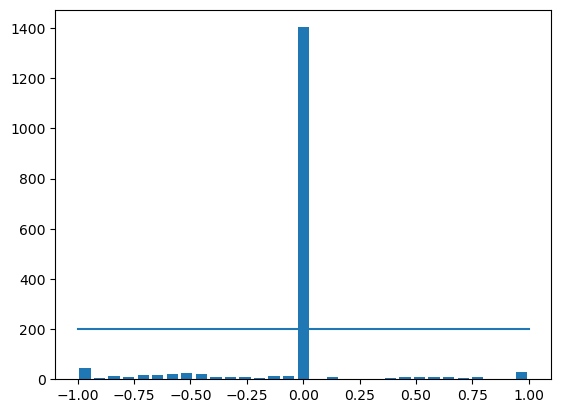

In [5]:
num_bins = 31
samples_per_bin = 200
hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5

plt.bar(center, hist, width=0.05)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

<h2 style="color: brown;">Fonction pour charger les images et les angles de direction</h2>

### Fonction `load_img_steering`

Cette fonction prend deux paramètres en entrée :
- `datadir` : Le répertoire où se trouvent les images.
- `df` : Un DataFrame contenant les chemins d'accès aux images et les valeurs de direction.

Elle retourne deux tableaux NumPy :
- `image_paths` : Contenant les chemins d'accès complets aux images.
- `steerings` : Contenant les valeurs de direction correspondantes.

#### Description du code :
1. Initialisation des listes `image_path` et `steering` pour stocker respectivement les chemins d'accès aux images et les valeurs de direction.
2. Boucle sur les lignes du DataFrame `df`.
3. À chaque itération :
   - Extraction des données de la ligne courante du DataFrame.
   - Récupération des chemins d'accès aux images des caméras centrale, gauche et droite.
   - Concaténation du chemin d'accès de l'image avec le répertoire `datadir` et ajout à la liste `image_path`.
   - Extraction de la valeur de direction et ajout à la liste `steering`.
4. Conversion des listes en tableaux NumPy à l'aide de `np.asarray`.
5. Retour des tableaux `image_paths` et `steerings`.


In [96]:
def load_img_steering(datadir, df):
    image_path = []
    steering = []
    for i in range(len(data)):
        indexed_data = data.iloc[i]
        center, left, right = indexed_data[0], indexed_data[1], indexed_data[2]
        image_path.append(os.path.join(datadir, center.strip()))
        steering.append(float(indexed_data[3]))
    image_paths = np.asarray(image_path)
    steerings = np.asarray(steering)
    return image_paths, steerings

La ligne de code ci-dessus appelle la fonction `load_img_steering` avec deux arguments :

- `datadir + '/IMG'` : Cela spécifie le répertoire contenant les images, où `datadir` est le répertoire racine et '/IMG' est le sous-répertoire où se trouvent les images. Ces deux parties sont concaténées pour former le chemin complet vers le répertoire des images.

- `data` : Ceci est le DataFrame qui contient les informations sur les images et les valeurs de direction. Il est passé à la fonction pour extraire les chemins d'accès aux images et les valeurs de direction correspondantes.

Enfin, la fonction `load_img_steering` retourne deux tableaux : `image_paths` qui contient les chemins d'accès aux images, et `steerings` qui contient les valeurs de direction associées à chaque image. Ces tableaux sont récupérés et stockés dans les variables `image_paths` et `steerings`.


In [97]:
image_paths, steerings = load_img_steering(datadir + '/IMG', data)

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_10324\2484579945.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center, left, right = indexed_data[0], indexed_data[1], indexed_data[2]
C:\Users\Administrateur\AppData\Local\Temp\ipykernel_10324\2484579945.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  steering.append(float(indexed_data[3]))


<h2 style="color: brown;">Division des données en ensembles d'entraînement et de validation </h2>

In [114]:
X_train, X_valid, Y_train, Y_valid = train_test_split(image_paths, steerings, test_size=0.2, random_state=0)

<h2 style="color: brown;">Prétraitement des images </h2>

Cette fonction `img_preprocess` effectue un prétraitement sur une image donnée en entrée. Voici ce que chaque étape de prétraitement fait :

1. `img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)`: Convertit l'image de l'espace colorimétrique BGR (utilisé par OpenCV) à l'espace colorimétrique YUV. Cela peut aider le modèle à mieux capturer les caractéristiques de l'image pour la tâche de traitement des images de voiture autonome.

2. `img = cv2.GaussianBlur(img, (3, 3), 0)`: cv2.GaussianBlur est une fonction de OpenCV qui permet d'appliquer un filtre de flou gaussien à une image. Ce filtre est utilisé pour réduire le bruit etles détails indésirables tout en préservant les caractéristiques importantes de l'image..

3. `img = cv2.resize(img, (200, 66))`: Redimensionne l'image à une taille de (200, 66). Cette taille est couramment utilisée pour les images dans les applications de voiture autonome et est probablement adaptée à la taille d'entrée attendue par le modèle de voiture autonome.

4. `img = img / 255`: Normalise les valeurs de pixel de l'image pour qu'elles soient dans la plage [0, 1]. Cela aide le modèle à converger plus rapidement lors de l'entraînement en mettant à l'échelle les valeurs des pixels.

En résumé, cette fonction prétraite l'image en convertissant son espace colorimétrique, en appliquant un flou gaussien, en redimensionnant l'image et en normalisant les valeurs des pixels, afin de préparer l'image à être utilisée comme entrée pour un modèle de voiture autonome.

In [98]:
def img_preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.resize(img, (200, 66))
    img = img / 255
    return img

<h2 style="color: brown;"> Visualisation de l'image originale et de l'image prétraitée</h2>

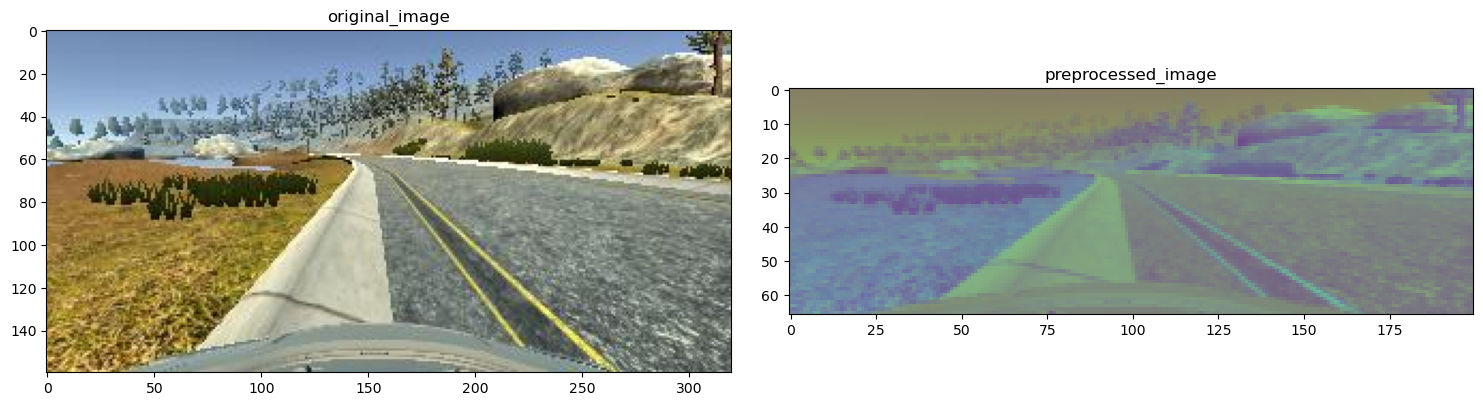

In [99]:
image = cv2.imread(image_paths[100])  # Load the original image
preprocessed_image = img_preprocess(image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Display the original image
axes[0].set_title('original_image')

# Convert the preprocessed image to 8-bit unsigned integer format
preprocessed_image_display = cv2.normalize(preprocessed_image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

axes[1].imshow(cv2.cvtColor(preprocessed_image_display, cv2.COLOR_BGR2YUV))
axes[1].set_title('preprocessed_image')

plt.show()


La conversion de l'image prétraitée en format d'entier non signé sur 8 bits (valeurs comprises entre 0 et 255) est nécessaire pour pouvoir l'afficher correctement avec matplotlib. Matplotlib attend des images sous ce format pour les afficher correctement. La fonction `cv2.normalize` est utilisée pour redimensionner et mettre à l'échelle les valeurs des pixels de l'image prétraitée afin qu'elles soient dans la plage attendue (0-255) pour un affichage correct. Ensuite, le paramètre `dtype=cv2.CV_8U` indique que les valeurs des pixels de l'image doivent être des entiers non signés sur 8 bits.

<h2 style="color: brown;"> Augmentation des données</h2>

In [100]:
import matplotlib.image as mpimg
from imgaug import augmenters as iaa

def augmentImage(imgPath, steering):
    img = mpimg.imread(imgPath)
    #pan
    if np.random.rand() < 0.5:
        pan = iaa.Affine(translate_percent={'x': (-0.1, 0.1), 'y': (-0.1, -0.1)})
        img = pan.augment_image(img)
    #Zoom
    if np.random.rand() < 0.5:
        zoom=iaa.Affine(scale=(1,1.2))
        img=zoom.augment_image(img)
    #BRIGHTNESS
    if np.random.rand() < 0.5:
        brightness=iaa.Multiply((0.4,1.2))
        img=brightness.augment_image(img)
    #FLIP
    if np.random.rand() < 0.5:
        img=cv2.flip(img,1)
        steering=-steering
    
    return img, steering

Cette fonction `augmentImage` prend en entrée le chemin d'accès à une image (`imgPath`) et un angle de direction (`steering`). Elle utilise la bibliothèque matplotlib pour lire l'image à partir du chemin d'accès, puis applique des transformations d'augmentation d'image aléatoires à cette image en fonction de différentes probabilités. Voici ce que chaque partie de la fonction fait :

1. `img = mpimg.imread(imgPath)`: Charge l'image à partir du chemin d'accès `imgPath` à l'aide de `mpimg.imread` de matplotlib.

2. **Panoramique (`pan`)** : Si un nombre aléatoire généré est inférieur à 0,5, cela signifie qu'il y a 50% de chances d'appliquer une augmentation de panoramique à l'image. La transformation `iaa.Affine(translate_percent={'x': (-0.1, 0.1), 'y': (-0.1, -0.1)})` déplace l'image horizontalement et verticalement d'un pourcentage aléatoire compris entre -10% et +10%.

3. **Zoom** : Même principe que le panoramique, mais cette fois, il y a 50% de chances d'appliquer un zoom à l'image. La transformation `iaa.Affine(scale=(1,1.2))` applique un facteur de zoom aléatoire compris entre 1 et 1,2.

4. **Luminosité** : Encore une fois, 50% de chances d'appliquer une augmentation de luminosité. La transformation `iaa.Multiply((0.4,1.2))` multiplie les valeurs de pixel de l'image par un facteur aléatoire compris entre 0,4 et 1,2, modifiant ainsi la luminosité de l'image.

5. **Retournement horizontal (`flip`)** : Avec une probabilité de 50%, l'image est retournée horizontalement en utilisant `cv2.flip(img,1)` et l'angle de direction est inversé (`steering=-steering`), simulant ainsi un virage dans la direction opposée.

En résumé, cette fonction prend une image et un angle de direction, et avec une certaine probabilité, elle applique différentes transformations d'augmentation d'image pour augmenter la variabilité des données d'entraînement.

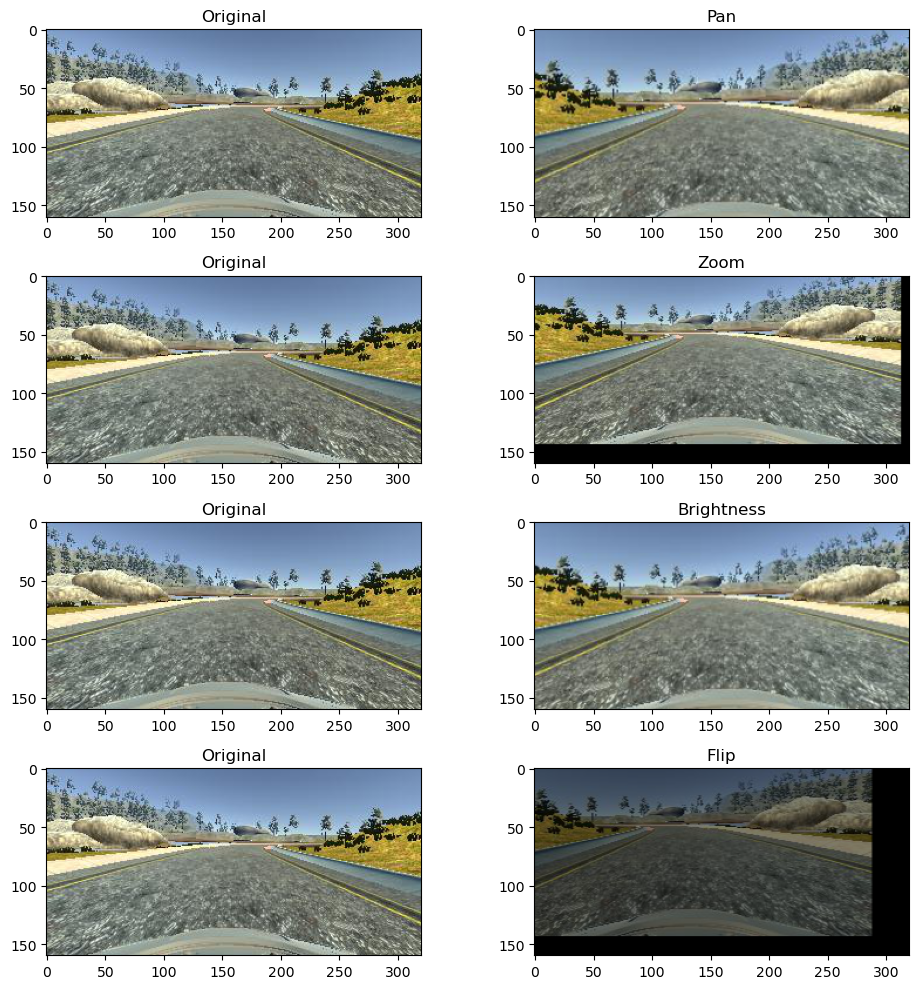

In [111]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Sélectionner une image au hasard pour afficher les transformations
random_index = np.random.randint(len(X_train))
img_path = X_train[random_index]
steering_angle = Y_train[random_index]

# Créer une figure avec plusieurs sous-graphiques
fig, axs = plt.subplots(4, 2, figsize=(10, 10))

# Afficher l'image originale dans la première colonne de chaque ligne
original_img = mpimg.imread(img_path)
for i in range(4):
    axs[i, 0].imshow(original_img)
    axs[i, 0].set_title("Original")

# Appliquer les transformations une par une et afficher à côté
transformations = ["Pan", "Zoom", "Brightness", "Flip"]
for i, transformation in enumerate(transformations):
    augmented_img, _ = augmentImage(img_path, steering_angle)
    axs[i, 1].imshow(augmented_img)
    axs[i, 1].set_title(transformation)

plt.tight_layout()
plt.show()

In [112]:
def batchGen(imagePath, steeringList, batchSize, trainFlag):
    while True:
        imageBatch = []
        steeringBatch = []
        for i in range(batchSize):
            index = random.randint(0, len(imagePath) - 1)
            if trainFlag:
                img, steering = augmentImage(imagePath[index], steeringList[index]) 
            else:
                img=npimg.imread(imagePath[index])
                steering=steeringList[index]
            img=img_preprocess(img)
            imageBatch.append(img)
            steeringBatch.append(steering)
        yield(np.asarray(imageBatch),np.asarray(steeringBatch))     

Cette fonction `batchGen` est un générateur Python qui produit des lots de données pour l'entraînement d'un modèle de voiture autonome. Voici ce que chaque partie de la fonction fait :

1. `while True:` : Cela crée une boucle infinie, ce qui signifie que ce générateur continuera à produire des lots de données indéfiniment.

2. `imageBatch = []` et `steeringBatch = []` : Ces deux lignes initialisent des listes vides pour stocker les images et les angles de direction correspondants pour chaque lot.

3. `for i in range(batchSize):` : Cette boucle génère un lot de données de taille `batchSize`.

4. `index = random.randint(0, len(imagePath) - 1)` : Cela génère un indice aléatoire pour sélectionner une image et son angle de direction correspondant à partir des listes `imagePath` et `steeringList`.

5. `if trainFlag:` : Vérifie si `trainFlag` est vrai. Si c'est le cas, cela signifie que nous sommes en mode entraînement, et nous devons augmenter l'image à l'aide de la fonction `augmentImage` et utiliser l'angle de direction correspondant. Sinon, nous chargeons simplement l'image à l'aide de `mpimg.imread` sans l'augmenter.

6. `img = img_preprocess(img)` : Applique un prétraitement à l'image en utilisant la fonction `img_preprocess` pour convertir l'image en niveaux de gris, appliquer un flou gaussien, redimensionner et normaliser les valeurs de pixel.

7. `imageBatch.append(img)` et `steeringBatch.append(steering)` : Ajoute l'image prétraitée et l'angle de direction correspondant aux listes de lots d'images et d'angles de direction.

8. `yield(np.asarray(imageBatch),np.asarray(steeringBatch))` : Renvoie un lot d'images et d'angles de direction sous forme de tableaux numpy. La fonction `yield` permet de renvoyer les données du lot sans interrompre l'exécution de la fonction, ce qui en fait un générateur.

En résumé, la fonction batchGen est essentielle pour prétraiter et augmenter les données d'entraînement de manière efficace, ce qui peut contribuer à améliorer les performances du modèle de voiture autonome en lui permettant d'apprendre à partir d'une plus grande variété de situations.

`trainFlag` est un paramètre utilisé dans la fonction `batchGen` pour déterminer si le générateur est utilisé en mode d'entraînement ou en mode d'évaluation (par exemple, validation ou test). Lorsque `trainFlag=True`, cela signifie que le générateur est utilisé en mode d'entraînement, et il applique des augmentations aux images (comme le retournement horizontal, le panoramique, le zoom, etc.) pour augmenter la diversité des données d'entraînement. Cela permet d'améliorer la capacité du modèle à généraliser à de nouvelles situations et à être plus robuste.

En revanche, lorsque `trainFlag=False`, le générateur est utilisé en mode d'évaluation (par exemple, validation ou test), et il ne fait pas d'augmentations aux images. Il se contente de charger les images et les angles de direction correspondants sans aucune modification, ce qui permet d'évaluer les performances du modèle sur des données non modifiées.

Ainsi, `trainFlag` contrôle le comportement du générateur en fonction du mode dans lequel il est utilisé, ce qui est important pour garantir que le modèle est entraîné et évalué de manière appropriée.

In [105]:
# Nombre de données avant l'augmentation
nb_data_avant_augmentation = len(X_train)

# Générer les données augmentées
batch_size = 20
train_generator = batchGen(X_train, Y_train, batch_size, trainFlag=True)

# Calculer le nombre de données après l'augmentation
nb_data_apres_augmentation = batch_size * 1000  # 1000 étapes par époque

print("Nombre de données avant augmentation :", nb_data_avant_augmentation)
print("Nombre de données après augmentation :", nb_data_apres_augmentation)

Nombre de données avant augmentation : 1394
Nombre de données après augmentation : 20000


<h2 style="color: brown;"> Définition de l'architecture du modèle </h2>

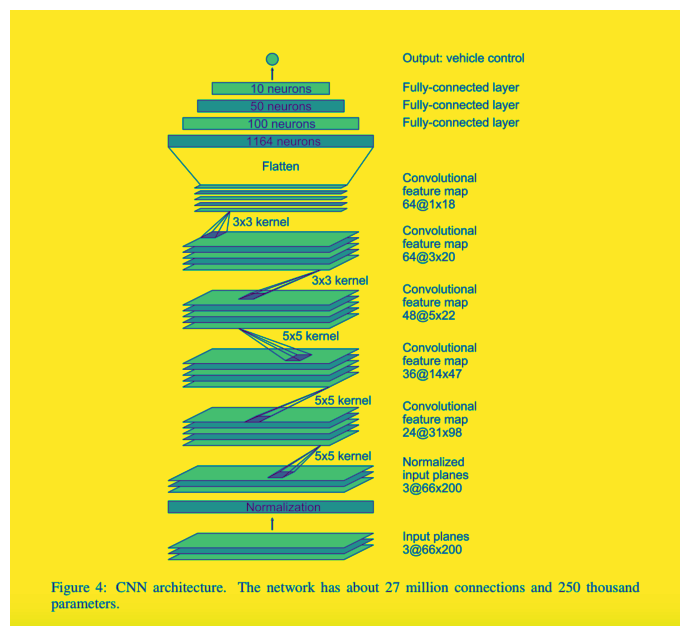

In [109]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Charger l'image depuis un fichier
img = mpimg.imread('model_achitecture.png')

# Définir la taille de l'image affichée
plt.figure(figsize=(20, 8))  # Taille de l'image en pouces (largeur, hauteur)
plt.imshow(img)
plt.axis('off')  # Masquer les axes
plt.show()

Ce code définit une fonction `createModel` qui crée et compile un modèle de réseau neuronal pour la conduite autonome. Voici ce que chaque partie du code fait :

- `IMAGE_HEIGHT`, `IMAGE_WIDTH`, `IMAGE_CHANNELS` : Ces constantes définissent les dimensions des images d'entrée. Dans ce cas, les images sont redimensionnées à 66x200 pixels avec 3 canaux de couleur (RVB).

- `INPUT_SHAPE` : Cette variable définit la forme de l'entrée du modèle, basée sur les dimensions des images définies précédemment.

- `createModel` : Cette fonction crée un modèle séquentiel, qui est une pile linéaire de couches. Le modèle commence par une couche Lambda qui normalise les valeurs des pixels des images d'entrée. Ensuite, il comporte plusieurs couches Conv2D pour extraire les caractéristiques des images, suivies de couches entièrement connectées (Dense) pour la prédiction de la direction de conduite.

- Les couches Conv2D sont des couches de convolution qui appliquent des filtres pour extraire des caractéristiques spatiales des images. Chaque couche est suivie d'une fonction d'activation ELU (Exponential Linear Unit) pour introduire de la non-linéarité.

- Les couches Dense sont des couches entièrement connectées qui prennent en entrée les caractéristiques extraites par les couches Conv2D et effectuent une classification ou une régression pour prédire la direction de conduite.

- Les régularisations L1 sont utilisées pour éviter le surapprentissage en ajoutant une pénalité sur les coefficients du modèle.

- Le modèle est compilé avec l'optimiseur Adam pour minimiser la perte quadratique moyenne (mse) entre les prédictions et les vraies valeurs de direction. La métrique de précision (accuracy) n'est pas très utile pour la régression et n'est donc pas souvent utilisée.

- La méthode 'summary()' est ensuite appelée pour afficher un résumé du modèle, montrant le type de chaque couche et le nombre de paramètres entraînables.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Lambda, Conv2D, Flatten, Dense
from tensorflow.keras.regularizers import l1
from tensorflow.keras.optimizers import Adam

IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS = 66, 200, 3
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS)

def createModel():
    model = Sequential()
    model.add(Lambda(lambda x: x/127.5-1.0, input_shape=INPUT_SHAPE))
    model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(64, (3, 3), activation='elu'))
    model.add(Conv2D(64, (3, 3), activation='elu'))
    model.add(Flatten())
    model.add(Dense(100, activation='elu', kernel_regularizer=l1(0.001)))
    model.add(Dense(50, activation='elu', kernel_regularizer=l1(0.001)))
    model.add(Dense(10, activation='elu', kernel_regularizer=l1(0.001)))
    model.add(Dense(1))
    model.compile(Adam(lr=0.0001), loss='mse', metrics=['accuracy'])
    
    return model

model = createModel()
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda (Lambda)             (None, 66, 200, 3)        0         
                                                                 
 conv2d (Conv2D)             (None, 31, 98, 24)        1824      
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 47, 36)        21636     
                                                                 
 conv2d_2 (Conv2D)           (None, 5, 22, 48)         43248     
                                                                 
 conv2d_3 (Conv2D)           (None, 3, 20, 64)         27712     
                                                                 
 conv2d_4 (Conv2D)           (None, 1, 18, 64)         36928     
                                                                 
 flatten (Flatten)           (None, 1152)              0

Ce code importe le module `time` de Python pour travailler avec le temps et le module `TensorBoard` des rappels (callbacks) de Keras pour créer un objet TensorBoard.

- `import time`: Importe le module Python `time`, qui fournit des fonctionnalités pour travailler avec le temps, telles que la mesure du temps écoulé.

- `from tensorflow.keras.callbacks import TensorBoard`: Importe la classe `TensorBoard` du module `callbacks` de TensorFlow.keras. `TensorBoard` est un outil de visualisation fourni avec TensorFlow qui permet de suivre et de visualiser les métriques et les performances des modèles pendant l'entraînement.

- `log_file_name = f'automobile_autonome{int(time.time())}'`: Crée un nom de fichier de journal pour les données TensorBoard en combinant le préfixe 'automobile_autonome' avec le temps actuel en secondes depuis l'époque Unix (le 1er janvier 1970). Cela garantit que chaque exécution du script aura un nom de fichier unique.

- `tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')`: Crée un objet `TensorBoard` qui sera utilisé comme rappel (callback) lors de l'entraînement d'un modèle. Le paramètre `log_dir` spécifie le répertoire où les données de journal seront enregistrées. Dans ce cas, les données sont enregistrées dans un sous-répertoire appelé 'logs' avec le nom de fichier généré précédemment. Ces données pourront être visualisées à l'aide de TensorBoard.


<h2 style="color: brown;">Enregistrement du modèle</h2>

In [16]:
import time
from tensorflow.keras.callbacks import TensorBoard

log_file_name = f'automobile_autonome{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')


# checkpoint

Ce code définit un point de contrôle pour sauvegarder le modèle pendant l'entraînement. 

- `from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard`: Importe les classes ModelCheckpoint et TensorBoard du module callbacks de TensorFlow.keras.

- `filepath = "cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}"`: Définit le nom de fichier pour le modèle sauvegardé. Ce nom de fichier contient deux variables formatées :
    - `{epoch:02d}` : Époque de l'entraînement, formatée pour avoir toujours deux chiffres.
    - `{val_accuracy:.2f}` : Précision de validation (development) formatée pour afficher deux chiffres après la virgule.
    
- `checkpoint = ModelCheckpoint("models/{}.model".format(filepath), monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')`: Crée un point de contrôle pour sauvegarder le modèle. Les principaux paramètres sont :
    - `"models/{}.model".format(filepath)"`: Chemin où le modèle sauvegardé sera stocké, avec le nom de fichier basé sur le format défini par `filepath`.
    - `monitor='val_accuracy'` : Métrique à surveiller. Dans ce cas, il s'agit de la précision de validation (development).
    - `verbose=1` : Affiche un message lorsque le modèle est sauvegardé.
    - `save_best_only=True` : Ne sauvegarde que le meilleur modèle (selon la métrique surveillée).
    - `mode='max'` : Indique que le meilleur modèle est celui qui maximise la métrique surveillée (dans ce cas, la précision de validation).


In [18]:
# nom de fichier unique qui inclura l'époque et la précision de validation (development)
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
filepath = "cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}"

# sauvegarder le modèle avec la meilleure précision de validation (development) jusqu'à présent
checkpoint = ModelCheckpoint("models/{}.model".format(filepath), monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')


<h2 style="color: brown;">Entraînement du modèle </h2>

In [19]:


# Entraîner le modèle en utilisant les callbacks ModelCheckpoint et TensorBoard
history = model.fit(batchGen(X_train, Y_train, 20, 1), steps_per_epoch=1000, epochs=25,
                    validation_data=batchGen(X_valid, Y_valid, 20, 0), validation_steps=20,
                    callbacks=[checkpoint, tensorboard])


Epoch 1/25



1000/1000 [==============================] - ETA: 0s - loss: 0.9202 - accuracy: 0.7796
Epoch 1: val_accuracy improved from -inf to 0.81000, saving model to models\cnn-parameters-improvement-01-0.81.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-01-0.81.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-01-0.81.model\assets


1000/1000 [==============================] - 393s 378ms/step - loss: 0.9202 - accuracy: 0.7796 - val_loss: 0.1424 - val_accuracy: 0.8100
Epoch 2/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1334 - accuracy: 0.7860
Epoch 2: val_accuracy improved from 0.81000 to 0.82500, saving model to models\cnn-parameters-improvement-02-0.82.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-02-0.82.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-02-0.82.model\assets


1000/1000 [==============================] - 310s 310ms/step - loss: 0.1334 - accuracy: 0.7860 - val_loss: 0.0827 - val_accuracy: 0.8250
Epoch 3/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1118 - accuracy: 0.7844
Epoch 3: val_accuracy did not improve from 0.82500
1000/1000 [==============================] - 300s 301ms/step - loss: 0.1118 - accuracy: 0.7844 - val_loss: 0.0822 - val_accuracy: 0.7925
Epoch 4/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1087 - accuracy: 0.7882
Epoch 4: val_accuracy did not improve from 0.82500
1000/1000 [==============================] - 287s 288ms/step - loss: 0.1087 - accuracy: 0.7882 - val_loss: 0.0603 - val_accuracy: 0.8250
Epoch 5/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1097 - accuracy: 0.7815
Epoch 5: val_accuracy improved from 0.82500 to 0.84750, saving model to models\cnn-parameters-improvement-05-0.85.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-05-0

INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-05-0.85.model\assets


1000/1000 [==============================] - 296s 296ms/step - loss: 0.1097 - accuracy: 0.7815 - val_loss: 0.0707 - val_accuracy: 0.8475
Epoch 6/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1092 - accuracy: 0.7831
Epoch 6: val_accuracy did not improve from 0.84750
1000/1000 [==============================] - 215s 215ms/step - loss: 0.1092 - accuracy: 0.7831 - val_loss: 0.0779 - val_accuracy: 0.8150
Epoch 7/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1109 - accuracy: 0.7778
Epoch 7: val_accuracy improved from 0.84750 to 0.87250, saving model to models\cnn-parameters-improvement-07-0.87.model
INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-07-0.87.model\assets


INFO:tensorflow:Assets written to: models\cnn-parameters-improvement-07-0.87.model\assets


1000/1000 [==============================] - 228s 228ms/step - loss: 0.1109 - accuracy: 0.7778 - val_loss: 0.0471 - val_accuracy: 0.8725
Epoch 8/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1130 - accuracy: 0.7787
Epoch 8: val_accuracy did not improve from 0.87250
1000/1000 [==============================] - 227s 228ms/step - loss: 0.1130 - accuracy: 0.7787 - val_loss: 0.0709 - val_accuracy: 0.8225
Epoch 9/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1092 - accuracy: 0.7812
Epoch 9: val_accuracy did not improve from 0.87250
1000/1000 [==============================] - 220s 220ms/step - loss: 0.1092 - accuracy: 0.7812 - val_loss: 0.0670 - val_accuracy: 0.8300
Epoch 10/25
1000/1000 [==============================] - ETA: 0s - loss: 0.1088 - accuracy: 0.7814
Epoch 10: val_accuracy did not improve from 0.87250
1000/1000 [==============================] - 232s 232ms/step - loss: 0.1088 - accuracy: 0.7814 - val_loss: 0.0620 - val_accuracy: 0.8475
Epo

Cet exemple de code montre comment entraîner un modèle en utilisant les callbacks `ModelCheckpoint` et `TensorBoard` avec la méthode `fit` de Keras. Voici ce que chaque partie du code fait :

1. `model.fit(...)`: Cette méthode entraîne le modèle en utilisant les données générées par le générateur `batchGen`. Les paramètres `X_train` et `Y_train` sont les données d'entraînement, et `X_valid` et `Y_valid` sont les données de validation. Les paramètres `steps_per_epoch` et `validation_steps` définissent le nombre d'étapes par époque pour l'entraînement et la validation, respectivement.

2. `callbacks=[checkpoint, tensorboard]`: Les callbacks sont des objets spéciaux de Keras qui permettent d'effectuer des actions à des moments spécifiques lors de l'entraînement du modèle. Dans cet exemple, `checkpoint` est un callback `ModelCheckpoint` qui sauvegarde le modèle à la fin de chaque époque si la performance sur les données de validation s'est améliorée. `tensorboard` est un callback `TensorBoard` qui permet de visualiser les métriques d'entraînement dans TensorBoard.

En résumé, cet exemple de code montre comment utiliser les callbacks `ModelCheckpoint` et `TensorBoard` pour sauvegarder le modèle et visualiser les métriques d'entraînement pendant l'entraînement.

In [20]:
history = model.history.history

In [21]:
for key in history.keys():
    print(key)

loss
accuracy
val_loss
val_accuracy


<h2 style="color: brown;">Visualisation de l'historique d'apprentissage (loss) </h2>

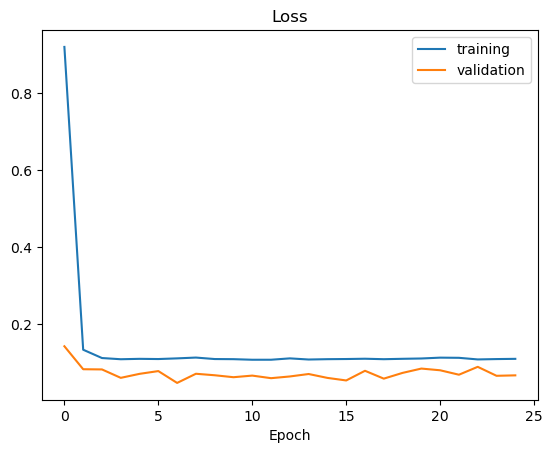

In [22]:
import matplotlib.pyplot as plt

plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.legend(['training', 'validation'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()


<h2 style="color: brown;">Évaluation du modèle sur les données de validation</h2>

In [36]:
result = model.evaluate(batchGen(X_valid, Y_valid, 10, 0), steps=10)
print(f'Loss: {result[0]}, Accuracy: {result[1]}')


10/10 [==============================] - 0s 43ms/step - loss: 0.0404 - accuracy: 0.8900
Loss: 0.0403580442070961, Accuracy: 0.8899999856948853


<h2 style="color: brown;">Chargement du modèle et évaluation</h2>

In [84]:
import numpy as np
from keras.models import load_model
from sklearn.metrics import confusion_matrix, accuracy_score
# Charger le modèle Keras
best_model= load_model("models/cnn-parameters-improvement-05-0.88.model")



In [85]:
best_model.metrics_names

['loss', 'accuracy']

In [92]:
loss, acc = best_model.evaluate(batchGen(X_valid, Y_valid, 10, 0), steps=10)

10/10 [==============================] - 0s 36ms/step - loss: 0.0445 - accuracy: 0.8900


In [93]:
# Faire des prédictions sur les données de validation
y_pred_prob = best_model.predict(batchGen(X_valid, Y_valid, 10, 0), steps=10)

# Convertir les probabilités en classes prédites
y_pred = np.argmax(y_pred_prob, axis=1)

# Afficher les prédictions
print(y_pred)


10/10 [==============================] - 1s 37ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [94]:
pip install tensorflow tensorboard


^C
Note: you may need to restart the kernel to use updated packages.


In [95]:
%load_ext tensorboard
%tensorboard --logdir logs


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\radam-0.0.1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
